## About
relatively well performing but poor scoreing so it has to be tweaked but could be nice to show in work
 

In [444]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn

In [445]:
import sys, os
sys.path.append(os.path.abspath(".."))
from src.plotting_styles import apply_global_style

In [446]:
from src.load_sam_data import load_dataset
from src.autoencoders import drop_empty_histograms
from src.autoencoders import minmax_scale_per_sample

dataset = load_dataset("FJ")
full_dataset = np.array(dataset)
full_dataset = minmax_scale_per_sample(full_dataset)

dataset_no_outs = drop_empty_histograms(full_dataset)

..\data\FJ\FI01X1\FI01X1_ch
Dropped indexes [8, 15, 188, 214, 263, 268, 533, 546]


In [447]:
from sklearn.model_selection import train_test_split

X_train, X_test = train_test_split(dataset_no_outs, shuffle=True, train_size=0.8, random_state=42)

In [448]:
dataset_no_outs = torch.from_numpy(dataset_no_outs)
X_train = torch.from_numpy(X_train)
X_test = torch.from_numpy(X_test)
full_dataset = torch.from_numpy(full_dataset)

dataset_no_outs = dataset_no_outs.to(torch.float32)
X_train = X_train.to(torch.float32)
X_test = X_test.to(torch.float32)
full_dataset = full_dataset.to(torch.float32)

In [449]:
from torch.utils.data import Dataset, DataLoader

class HistDataset(Dataset):
    def __init__(self, df):
        self.df = df

    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        x = self.df[idx]

        if not torch.is_tensor(x):
            x = torch.tensor(x, dtype=torch.float32)
        
        x = x.unsqueeze(0)
        return x

In [450]:
pt = dataset[34]

# to get the actual lenght
pt_len = len(pt)
print(type(pt))
pt = torch.tensor(pt.reshape(1, 1, pt_len))
encoder = nn.Sequential(
            nn.Conv1d(1, 1, kernel_size=3),  
            nn.BatchNorm1d(1),
            nn.ReLU(),
            
            nn.Conv1d(1, 1, kernel_size=3, stride=2, padding=1),  
            nn.BatchNorm1d(1),
            nn.ReLU(),

            
            nn.Conv1d(1, 1, kernel_size=3, stride=2, padding=1), 
            nn.BatchNorm1d(1),
            nn.Sigmoid()
        )

print(f"The encoded data shape: {encoder(pt).shape}")

<class 'numpy.ndarray'>
The encoded data shape: torch.Size([1, 1, 24])


In [451]:
class AE_old(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.encoder = nn.Sequential(
            nn.Conv1d(1, 2, kernel_size=3),  
            nn.BatchNorm1d(2),
            nn.ReLU(),
            
            nn.Conv1d(2, 4, kernel_size=3, stride=2, padding=1),  
            nn.BatchNorm1d(4),
            nn.ReLU(),

           # nn.Conv1d(1, 1, kernel_size=3, stride=2, padding=1), 
          #  nn.BatchNorm1d(1),
           # nn.Sigmoid()
        )
        
        self.decoder = nn.Sequential(
           # nn.ConvTranspose1d(1, 1, kernel_size=3, stride=2),  
           # nn.BatchNorm1d(1),
           # nn.ReLU(),
            
            nn.Conv1d(2, 4, kernel_size=3, stride=2, padding=1),  
            nn.BatchNorm1d(4),
            nn.ReLU(),
            
            nn.ConvTranspose1d(4, 2, kernel_size=3, stride=2),
            nn.BatchNorm1d(2),
            nn.Sigmoid()
        )
        
    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x


In [452]:
import torch
import torch.nn as nn

class Residual1D(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(c, c, 3, padding=1),
            nn.BatchNorm1d(c),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Conv1d(c, c, 3, padding=1),
            nn.BatchNorm1d(c),
        )
        self.act = nn.LeakyReLU(0.1, inplace=True)
    def forward(self, x):
        return self.act(x + self.block(x))

class AE(nn.Module):
    def __init__(self, latent_dim=32):
        super().__init__()

        # ---- Encoder ----
        self.enc = nn.Sequential(
            nn.Conv1d(1, 16, 3, stride=2, padding=1),   # 96 → 48
            nn.BatchNorm1d(16),
            nn.LeakyReLU(0.1, inplace=True),
            Residual1D(16),

            nn.Conv1d(16, 32, 3, stride=2, padding=1), # 48 → 24
            nn.BatchNorm1d(32),
            nn.LeakyReLU(0.1, inplace=True),
            Residual1D(32),

            nn.Conv1d(32, latent_dim, 3, stride=2, padding=1), # 24 → 12
            nn.BatchNorm1d(latent_dim),
            nn.LeakyReLU(0.1, inplace=True),
        )

        # ---- Decoder ----
        self.dec = nn.Sequential(
            nn.ConvTranspose1d(latent_dim, 32, 4, stride=2, padding=1), # 12 → 24
            nn.BatchNorm1d(32),
            nn.LeakyReLU(0.1, inplace=True),
            Residual1D(32),

            nn.ConvTranspose1d(32, 16, 4, stride=2, padding=1), # 24 → 48
            nn.BatchNorm1d(16),
            nn.LeakyReLU(0.1, inplace=True),
            Residual1D(16),

            nn.ConvTranspose1d(16, 1, 4, stride=2, padding=1), # 48 → 96
            nn.Sigmoid()  # Since data is [0,1]
        )

    def forward(self, x):
        z = self.enc(x)
        out = self.dec(z)
        return out

In [453]:
batch_size = 32
train_dataset = HistDataset(X_train)
test_dataset = HistDataset(X_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

ae_conv = AE()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(params=ae_conv.parameters(), lr=0.00005)

In [454]:
from src.autoencoders import train_ae

ae_conv.train()
train_losses, val_losses, ae_conv = train_ae(n_epochs=40, dataloader=train_loader, model=ae_conv, val_loader=test_loader, optimizer=optimizer, criterion=criterion)

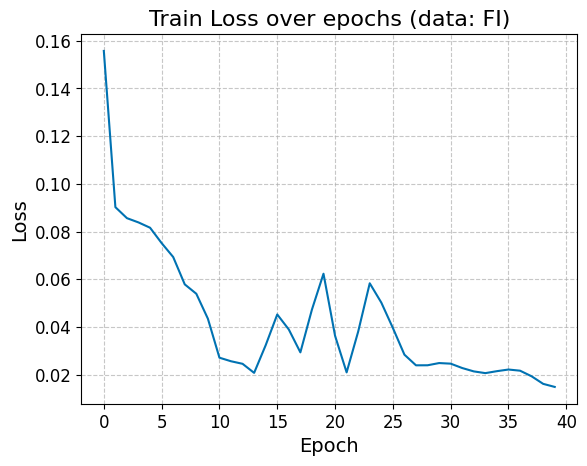

In [455]:
apply_global_style()
plt.title("Train Loss over epochs (data: FI)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.plot(range(len(train_losses)), train_losses)
plt.show()

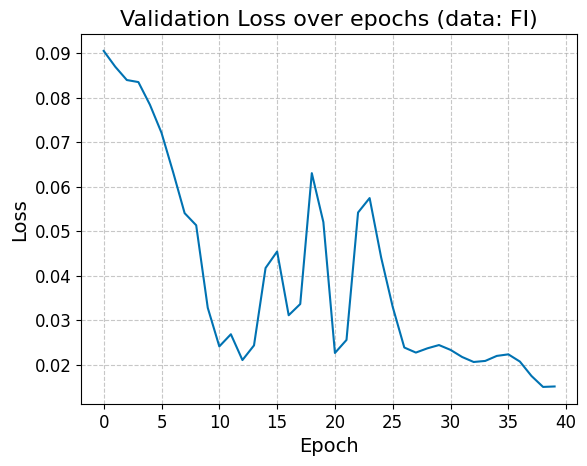

In [456]:
apply_global_style()
plt.title("Validation Loss over epochs (data: FI)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.plot(range(len(val_losses)), val_losses)
plt.show()

In [457]:
full_dataset = HistDataset(full_dataset)
dataloader = DataLoader(full_dataset, batch_size=batch_size, shuffle=False)

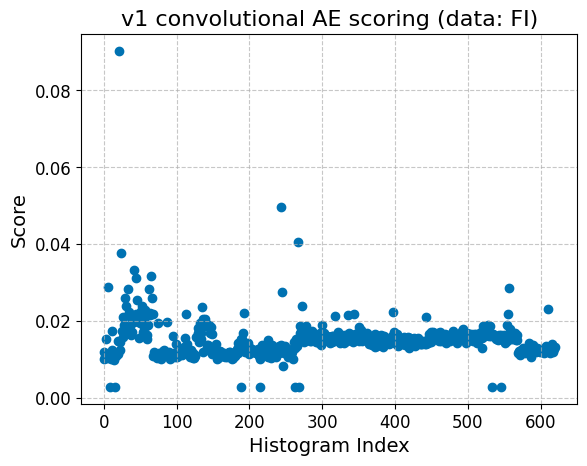

In [458]:
from src.autoencoders import eval_and_plot_score
apply_global_style()
plt.title("v1 convolutional AE scoring (data: FI)")
plt.xlabel("Histogram Index")
plt.ylabel("Score")
model=ae_conv
model.eval()
score = []

with torch.no_grad():
    for pt in full_dataset:
        pt = pt.unsqueeze(1)
        pred = ae_conv(pt)
        loss = criterion(pred, pt).detach().numpy()
        score.append(loss)

#score = eval_and_plot_score(model=ae_conv, dataloader=dataloader, criterion=criterion)
plt.scatter(range(len(score)), score)
plt.show()

In [459]:
outliers = np.where(np.array(score) > 0.07)
outliers

(array([21]),)

In [460]:
import numpy as np

preds = []

with torch.no_grad():
    for idx, data in enumerate(full_dataset):
        pred = ae_conv(data.unsqueeze(1)).cpu().numpy().squeeze()
        
        for p in preds:
            if np.array_equal(pred, p):
                break
        else:
            preds.append(pred)

print(f"There are {len(preds)} unique representations that model outputs")

There are 613 unique representations that model outputs


In [461]:
preds[9]

array([0.15338205, 0.11408909, 0.02814419, 0.06368485, 0.03080832,
       0.05258943, 0.01988238, 0.08282009, 0.06030988, 0.08534244,
       0.03005621, 0.09089234, 0.07179951, 0.1342704 , 0.0473153 ,
       0.20165454, 0.1579932 , 0.31650192, 0.23406777, 0.46254522,
       0.36018878, 0.4694658 , 0.42369446, 0.6680486 , 0.5827295 ,
       0.61406   , 0.7201041 , 0.67282176, 0.5859463 , 0.66147596,
       0.53172565, 0.78103906, 0.7096578 , 0.6618121 , 0.7426111 ,
       0.74026126, 0.642965  , 0.74655753, 0.60910255, 0.7879452 ,
       0.7369691 , 0.6724804 , 0.7502817 , 0.75312394, 0.6526384 ,
       0.7672417 , 0.61275214, 0.7768994 , 0.733951  , 0.654984  ,
       0.728321  , 0.74537146, 0.6265626 , 0.77728117, 0.57651937,
       0.7444004 , 0.67204255, 0.5477496 , 0.5392096 , 0.6112114 ,
       0.36999214, 0.626551  , 0.34830442, 0.40559754, 0.33170426,
       0.3112317 , 0.09839474, 0.17701685, 0.08198944, 0.10734662,
       0.03494022, 0.08395126, 0.06513   , 0.08896541, 0.02206

In [462]:
preds[6]

array([0.15359057, 0.11558369, 0.0273179 , 0.06547259, 0.02985073,
       0.05124366, 0.01851666, 0.07638642, 0.0526807 , 0.07207456,
       0.01937651, 0.07410698, 0.05046774, 0.08426751, 0.02892476,
       0.10141867, 0.06754985, 0.11663342, 0.05369902, 0.14401734,
       0.09852947, 0.19512172, 0.08040284, 0.28933743, 0.20431054,
       0.37824172, 0.283586  , 0.4685632 , 0.3554304 , 0.4616089 ,
       0.40043524, 0.6386258 , 0.5800596 , 0.59906846, 0.691293  ,
       0.6656682 , 0.5730941 , 0.6405758 , 0.5068905 , 0.78440315,
       0.7052658 , 0.66210836, 0.7436517 , 0.7463372 , 0.636897  ,
       0.7671124 , 0.59147805, 0.77221733, 0.72058004, 0.6507439 ,
       0.70944643, 0.72949827, 0.60950315, 0.76510036, 0.5610363 ,
       0.7138261 , 0.65178555, 0.5194591 , 0.48114064, 0.57593375,
       0.32470137, 0.5838619 , 0.28001404, 0.3655309 , 0.25809285,
       0.27712002, 0.07211009, 0.13671659, 0.0641799 , 0.08481282,
       0.02594628, 0.06797635, 0.05317854, 0.07853249, 0.01888

c:\Users\hrdyj\coding\vyzkumak\mlenv\Lib\site-packages\torch\nn\modules\loss.py:616: UserWarning: Using a target size (torch.Size([1, 96])) that is different to the input size (torch.Size([1, 1, 96])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


tensor(0.0137)


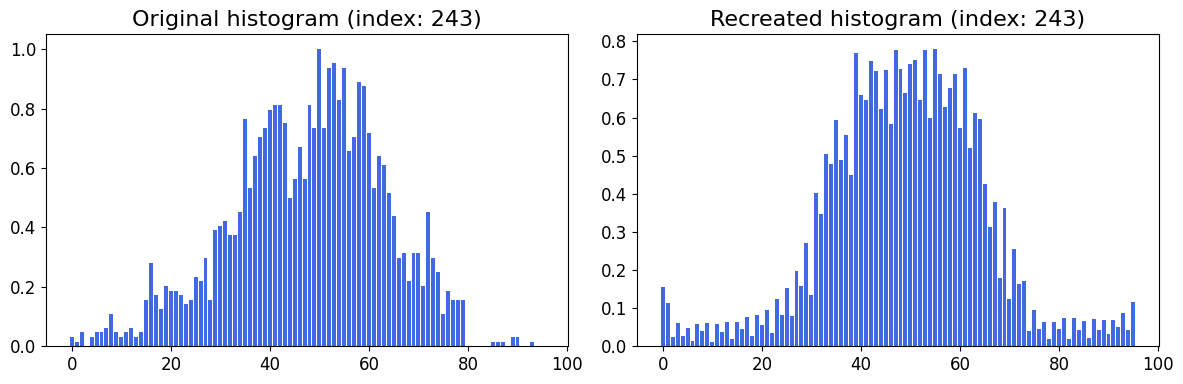

In [463]:
idx = 243

ae_conv.eval()
pred = ae_conv(full_dataset[idx].unsqueeze(1)).detach()

criterion = nn.MSELoss()
loss = criterion(pred, full_dataset[idx])
pred = pred.squeeze().numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(len(pred)), full_dataset[idx].squeeze(), zorder=1, color='royalblue')
axes[0].set_title(f"Original histogram (index: {idx})")
#axes[0].grid(True, linestyle='--', alpha=0.7, zorder=-2)

axes[1].bar(range(len(pred)), pred, zorder=1, color='royalblue')
axes[1].set_title(f"Recreated histogram (index: {idx})")
print(loss)
#axes[1].grid(True, linestyle='--', alpha=0.7, zorder=-2)

plt.tight_layout()
plt.show()

In [464]:
score_dict = {idx : s for idx, s in enumerate(score)}
indexes_sorted_by_score = sorted(score_dict, key=lambda x: score_dict[x], reverse=True)

print("highest scores", indexes_sorted_by_score[:10] )
print("lowest scores", indexes_sorted_by_score[-3:])

highest scores [21, 244, 267, 24, 41, 65, 44, 6, 556, 34]
lowest scores [268, 533, 546]


In [465]:
#torch.save(ae, 'functional_ae_conv_2.pth')

In [466]:
(dataset[0] == dataset[0]).all()

np.True_

In [467]:
preds = list()

with torch.no_grad():
    for idx, data in enumerate(dataset):
        data = data.unsqueeze(0)     
        pred = ae(data).numpy()
         
        for p in preds:
            if (pred == p).all():
                break
        else:
            preds.append(pred)
        
        if idx % 100 == 0: 
            print(idx)

AttributeError: 'numpy.ndarray' object has no attribute 'unsqueeze'